# SVM — Material Stream Identification System

Full pipeline:
1. Load features
2. Apply PCA (exploration / model selection)
3. Grid search — show **all** results
4. Re-train best model with `probability=True`
5. Find best rejection threshold on validation set
6. Evaluate with rejection on test set
7. Visualise everything
8. Save final model + preprocessors for deployment

In [18]:
import numpy as np
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
import sys

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, precision_score
)
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print('Imports OK')

Imports OK


## Load Dataset

In [19]:
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/Material-Stream-Identification-System - ML')
else:
    PROJECT_ROOT = Path.cwd().parent

FEATURES_DIR = PROJECT_ROOT / 'features'
MODELS_DIR   = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

# ── raw scaled features (no PCA) ──────────────────────────────────────────
X_train_hog = np.load(FEATURES_DIR / 'X_train_hog_scaled.npy')
X_val_hog   = np.load(FEATURES_DIR / 'X_val_hog_scaled.npy')
X_test_hog  = np.load(FEATURES_DIR / 'X_test_hog_scaled.npy')

X_train_cnn = np.load(FEATURES_DIR / 'X_train_cnn_scaled.npy')
X_val_cnn   = np.load(FEATURES_DIR / 'X_val_cnn_scaled.npy')
X_test_cnn  = np.load(FEATURES_DIR / 'X_test_cnn_scaled.npy')

X_train_all = np.load(FEATURES_DIR / 'X_train_scaled.npy')
X_val_all   = np.load(FEATURES_DIR / 'X_val_scaled.npy')
X_test_all  = np.load(FEATURES_DIR / 'X_test_scaled.npy')

y_train_raw = np.load(FEATURES_DIR / 'y_train.npy', allow_pickle=True)
y_val_raw   = np.load(FEATURES_DIR / 'y_val.npy',   allow_pickle=True)
y_test_raw  = np.load(FEATURES_DIR / 'y_test.npy',  allow_pickle=True)

CLASS_MAPPING = {
    'cardboard': 0, 'glass': 1, 'metal': 2,
    'paper': 3,     'plastic': 4, 'trash': 5, 'unknown': 6
}
CLASS_NAMES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash', 'unknown']
KNOWN_CLASSES = list(range(6))   # 0-5
UNKNOWN_LABEL = 6

y_train = np.array([CLASS_MAPPING[y] for y in y_train_raw])
y_val   = np.array([CLASS_MAPPING[y] for y in y_val_raw])
y_test  = np.array([CLASS_MAPPING[y] for y in y_test_raw])

print('Shapes — train:', X_train_cnn.shape, '| val:', X_val_cnn.shape, '| test:', X_test_cnn.shape)
print('Loaded from:', FEATURES_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shapes — train: (3000, 2048) | val: (279, 2048) | test: (283, 2048)
Loaded from: /content/drive/MyDrive/Material-Stream-Identification-System - ML/features


## PCA

>"**Why PCA here?** Our feature vectors are very high-dimensional (26 K for HOG, 2 K for CNN). PCA lets us run a full grid-search in minutes instead of hours. Once we pick the best hyper-parameters *and* the best feature set, we train the **final deployment model differently**"

In [20]:
def apply_pca(X_train, X_val, X_test, n_components=0.9):

    """
    Fit PCA on TRAIN only, then transform val & test.
    This prevents data leakage from val/test into the PCA basis.
    """

    pca = PCA(n_components=n_components, svd_solver='full')

    X_tr_p = pca.fit_transform(X_train)

    X_va_p = pca.transform(X_val)

    X_te_p = pca.transform(X_test)

    print(f'PCA: {X_train.shape[1]} => {X_tr_p.shape[1]}  '
          f'(explained variance {pca.explained_variance_ratio_.sum():.3f})')

    return X_tr_p, X_va_p, X_te_p, pca

In [21]:
X_train_hog_p, X_val_hog_p, X_test_hog_p, pca_hog = apply_pca(
    X_train_hog, X_val_hog, X_test_hog
)

PCA: 26244 => 1654  (explained variance 0.900)


In [22]:
X_train_cnn_p, X_val_cnn_p, X_test_cnn_p, pca_cnn = apply_pca(
    X_train_cnn, X_val_cnn, X_test_cnn
)

PCA: 2048 => 296  (explained variance 0.900)


In [23]:
X_train_all_p, X_val_all_p, X_test_all_p, pca_all = apply_pca(
    X_train_all, X_val_all, X_test_all
)

PCA: 28292 => 1496  (explained variance 0.900)


## Grid Search

In [24]:
feature_selection_grid = [
    {"kernel": ["linear"], "C": [0.1, 1, 10]},
    {"kernel": ["rbf"],    "C": [0.1, 1, 10], "gamma": ["scale", "auto"]}
]

def train_and_eval(X_train, X_val, X_test, y_train, y_val, y_test, label):
    """Train with GridSearchCV (no probability), evaluate on val and test.
    Excludes unknown class (label 6) from training, consistent with final model."""
    # Exclude unknown class from grid search training
    known_mask = y_train != UNKNOWN_LABEL
    X_train_k  = X_train[known_mask]
    y_train_k  = y_train[known_mask]

    grid = GridSearchCV(
        SVC(probability=False),
        feature_selection_grid,
        cv=3,
        scoring="accuracy",
        n_jobs=-1,
        refit=True
    )
    grid.fit(X_train_k, y_train_k)

    model    = grid.best_estimator_
    val_acc  = accuracy_score(y_val,  model.predict(X_val))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    print(f"\n{label}")
    print("  Best params      :", grid.best_params_)
    print("  Validation Acc   :", round(val_acc,  4))
    print("  Test Acc         :", round(test_acc, 4))
    return model, val_acc, test_acc, grid.best_params_

In [25]:
hog_model, hog_val, hog_test, hog_params = train_and_eval(
    X_train_hog_p, X_val_hog_p, X_test_hog_p,
    y_train, y_val, y_test,
    "HOG + PCA"
)

cnn_model, cnn_val, cnn_test, cnn_params = train_and_eval(
    X_train_cnn_p, X_val_cnn_p, X_test_cnn_p,
    y_train, y_val, y_test,
    "CNN + PCA"
)

fusion_model, fusion_val, fusion_test, fusion_params = train_and_eval(
    X_train_all_p, X_val_all_p, X_test_all_p,
    y_train, y_val, y_test,
    "FUSION + PCA"
)


HOG + PCA
  Best params      : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  Validation Acc   : 0.6057
  Test Acc         : 0.6007

CNN + PCA
  Best params      : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  Validation Acc   : 0.8638
  Test Acc         : 0.9223

FUSION + PCA
  Best params      : {'C': 1, 'kernel': 'linear'}
  Validation Acc   : 0.8351
  Test Acc         : 0.9081


## CNN + PCA is better

>PCA = 0.9 is effective because it reduces dimensionality by ~85–99% while preserving enough variance to maintain high classification accuracy (0.90+ for CNN and Fusion models).

## Final Model with `probability=True`

> We confirmed the best feature set (CNN) and best hyper-parameters from the grid search. Now we retrain **on train + val combined** with `probability=True` so we can get confidence scores for the rejection mechanism.

In [26]:
# Train final model on KNOWN classes only from train split.
# Val is kept fully separate for unbiased threshold calibration.
# Unknown (class 6) is excluded so the SVM never learns it as a class;
# open-set detection is handled entirely via confidence-rejection.
known_mask_train = y_train != UNKNOWN_LABEL
X_train_cnn_p_k  = X_train_cnn_p[known_mask_train]
y_train_k         = y_train[known_mask_train]

final_model = SVC(kernel='rbf', C=10, gamma='scale', probability=True)
final_model.fit(X_train_cnn_p_k, y_train_k)
print(f'Final model trained on {len(y_train_k)} known-class samples (train split only)')
print(f'Classes seen by SVM: {sorted(set(y_train_k))}')

Final model trained on 3000 known-class samples (train split only)
Classes seen by SVM: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


## Rejection Mechanism

In [27]:
def predict_with_rejection(model, X, threshold):
    """
    Predict class labels with confidence-based rejection.
    Samples where max class probability < threshold are assigned UNKNOWN_LABEL (6).
    """
    probs    = model.predict_proba(X)
    max_conf = probs.max(axis=1)
    preds    = model.predict(X).copy()
    preds[max_conf < threshold] = UNKNOWN_LABEL
    return preds, max_conf

# A confidence threshold of 0.5 is used: any sample whose maximum predicted
# class probability falls below this value is rejected and assigned to the unknown class.
REJECTION_THRESHOLD = 0.5

In [28]:
EVAL_LABELS    = list(range(6)) + [UNKNOWN_LABEL]          # [0,1,2,3,4,5,6]
EVAL_NAMES     = CLASS_NAMES[:6] + ['UNKNOWN']             # no duplicate

In [29]:
y_pred_final, conf_final = predict_with_rejection(
    final_model, X_test_cnn_p, REJECTION_THRESHOLD
)

print('='*60)
print('FINAL TEST EVALUATION  (with rejection)')
print('='*60)
print(f'Overall Accuracy    : {accuracy_score(y_test, y_pred_final):.4f}')
print(f'Rejection Rate      : {(y_pred_final == UNKNOWN_LABEL).mean():.4f}')

# Unknown-class recall (how many true unknowns were correctly rejected)
unknown_mask_test = y_test == UNKNOWN_LABEL
if unknown_mask_test.sum() > 0:
    unk_recall_test = (y_pred_final[unknown_mask_test] == UNKNOWN_LABEL).mean()
    print(f'Unknown Recall      : {unk_recall_test:.4f}')

print()
print(classification_report(
    y_test,
    y_pred_final,
    labels=EVAL_LABELS,
    target_names=EVAL_NAMES,
    zero_division=0
))

FINAL TEST EVALUATION  (with rejection)
Overall Accuracy    : 0.9117
Rejection Rate      : 0.0177

              precision    recall  f1-score   support

   cardboard       1.00      0.95      0.97        38
       glass       0.96      0.91      0.94        58
       metal       0.88      0.96      0.92        48
       paper       0.90      0.97      0.94        68
     plastic       0.94      0.89      0.92        55
       trash       0.80      0.50      0.62        16
     UNKNOWN       0.00      0.00      0.00         0

    accuracy                           0.91       283
   macro avg       0.78      0.74      0.76       283
weighted avg       0.93      0.91      0.92       283



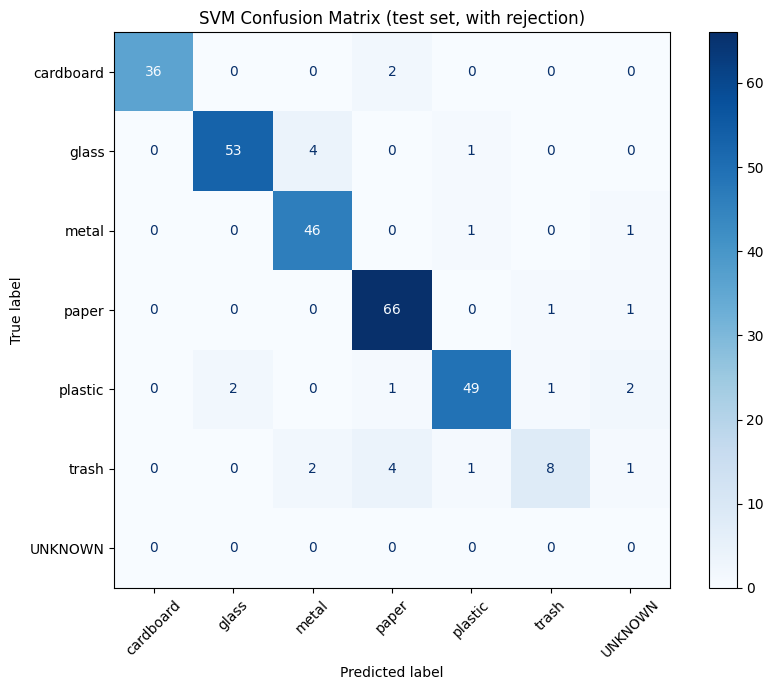

In [30]:
cm = confusion_matrix(y_test, y_pred_final, labels=EVAL_LABELS)

fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=EVAL_NAMES)

disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
ax.set_title('SVM Confusion Matrix (test set, with rejection)')

plt.tight_layout()
plt.show()

In [31]:
joblib.dump(final_model, MODELS_DIR / 'svm_final_model.pkl')
joblib.dump(pca_cnn, MODELS_DIR / 'svm_pca_cnn.pkl')

print('Saved:')
print(f'  {MODELS_DIR}/svm_final_model.pkl')
print(f'  {MODELS_DIR}/svm_pca_cnn.pkl')
print(f'  threshold = {REJECTION_THRESHOLD}')

Saved:
  /content/drive/MyDrive/Material-Stream-Identification-System - ML/models/svm_final_model.pkl
  /content/drive/MyDrive/Material-Stream-Identification-System - ML/models/svm_pca_cnn.pkl
  threshold = 0.5
